# Lung segmentation with Deep Learning models

Segmentation is a fundamental task in medical image processing. It consists of assigning a label to every pixel (or voxel) of an image in order to identify anatomical structures, organs, lesions, or devices. Modern approaches largely rely on deep learning, although obtaining large annotated medical datasets remains challenging.

In this hands-on lab, we focus on automatic lung segmentation from chest CT images and explore how segmentation methods have evolved over the last decade, from U-Nets to foundation models.

During the lab, we will:

- Explore a subset of the **COVID-19 CT Seg** dataset and define training, validation, and testing datasets
- Train a **U-Net** from scratch to understand the complete supervised segmentation workflow, encoder-decoder architecture, loss functions, and Dice-based evaluation.
- Use **SAM (Segment Anything Model)** to perform prompt-based segmentation from simple bounding-box annotations on both 2D slices and a complete 3D CT volume.
- Discover how **DINOv2** can be used as a frozen vision backbone and how foundation-model representations can be reused for downstream medical imaging tasks.

By the end of the lab, students will have been exposed to three major paradigms in modern medical image segmentation:

1. **Supervised segmentation** with U-Net
2. **Prompt-based fondation model segmentation** with SAM
3. **Foundation model representations** with DINOv2

Together, these approaches illustrate the evolution from task-specific neural networks toward increasingly general and reusable visual models in the AI research community.

## 0. Setup

#### **Install dependencies**

In [3]:
# Checking your notebook is working and python is available. You can create a dedicated environnement using "python -m venv chest_tp"
print("Hello world!")

Hello world!


In [4]:
# Setup can take several minutes (~6mn), if you already have some dependencies you can accelerate by commenting the corresponding install command lines.
!python --version
!pip --version

print('Installing common data processing librairies...')
!pip install -qq numpy scipy matplotlib tqdm Pillow scikit-image SimpleITK nibabel remotezip ipywidgets ipympl
print('Installing Pytorch for deep learning architectures...')
# !pip install -qq torch torchvision
!pip install -qq --upgrade torch torchvision --index-url https://download.pytorch.org/whl/cu128
print('Installing SAM model utilities...')
!pip install -qq segment-anything
!pip install -qq on ipympl ipywidgets
print('All dependencies installed!')

Python 3.12.6
pip 24.2 from C:\Users\250007508\OneDrive - GEHealthCare\Documents\4_Training\260808_Chest_MRI_School\chest_tp\Lib\site-packages\pip (python 3.12)

Installing common data processing librairies...
Installing Pytorch for deep learning architectures...
Installing SAM model utilities...
All dependencies installed!


In [5]:
# Download SAM checkpoint (~1mn)
import os, ssl, urllib.request

ssl._create_default_https_context = ssl._create_unverified_context

ckpt = "sam_vit_b_01ec64.pth"
if not os.path.exists(ckpt):
    print("Downloading SAM checkpoint...")
    urllib.request.urlretrieve(
        f"https://dl.fbaipublicfiles.com/segment_anything/{ckpt}",
        ckpt,
    )

print(f"SAM checkpoint: {os.path.getsize(ckpt)//1024**2} MB")

SAM checkpoint: 357 MB


In [6]:
# Import all the lib to check you have everything needed (~1mn)
import os
import re
import random
import zipfile
import urllib.request
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import SimpleITK as sitk
from pathlib import Path
import zipfile, requests
from remotezip import RemoteZip
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import ipympl

In [7]:
# Define a seed for reproducibility
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device used:", device)

Device used: cuda


#### **Download the datasets**

We download the dataset before the TP starts:

- 9 chest CT volumes from 8 different patients of the COVID-19 CT Lung and
  Infection Segmentation Dataset ([Ma et al., Zenodo 3757476](https://zenodo.org/records/3757476)),
- the matching expert lung masks.

Only a subdataset is downloaded to 

**Important:** Because we only have a handful of volumes, we split
at the patient level (not at the slice level) between train, validation and test dataset. Data leakage would otherwise gives inflated Dice scores.


In [8]:
# Data folders
CT_DATA_DIR = Path("data_chest_ct")
CT_IMG_DIR = CT_DATA_DIR / "volumes"
CT_MASK_DIR = CT_DATA_DIR / "masks"

for d in (CT_IMG_DIR, CT_MASK_DIR):
    d.mkdir(parents=True, exist_ok=True)

# 9 CT volumes
CT_CASES = """
radiopaedia_4_85506_1.nii.gz
radiopaedia_7_85703_0.nii.gz
radiopaedia_10_85902_1.nii.gz
radiopaedia_14_85914_0.nii.gz
radiopaedia_27_86410_0.nii.gz
radiopaedia_29_86490_1.nii.gz
radiopaedia_29_86491_1.nii.gz
radiopaedia_36_86526_0.nii.gz
radiopaedia_40_86625_0.nii.gz
""".split()

ZIP_IMG_URL = "https://zenodo.org/records/3757476/files/COVID-19-CT-Seg_20cases.zip"
ZIP_MSK_URL = "https://zenodo.org/records/3757476/files/Lung_Mask.zip"

# Disable SSL verification for corporate proxies
session = requests.Session()
session.verify = False

# Download selected CT volumes only
if not all((CT_IMG_DIR / c).exists() for c in CT_CASES):
    with RemoteZip(ZIP_IMG_URL, session=session) as rz:
        for c in CT_CASES:
            if not (CT_IMG_DIR / c).exists():
                rz.extract(c, path=CT_IMG_DIR)

# Download masks once
mask_zip = CT_DATA_DIR / "Lung_Mask.zip"
if not mask_zip.exists():
    mask_zip.write_bytes(session.get(ZIP_MSK_URL).content)

for c in CT_CASES:
    if not (CT_MASK_DIR / c).exists():
        with zipfile.ZipFile(mask_zip) as zf:
            zf.extract(c, path=CT_MASK_DIR)

print(f"Ready: {len(CT_CASES)} volumes")

Ready: 9 volumes


## 1. Dataset: 2D chest CT slices with lung masks

The volumes are already available on disk. For each CT scan, we:

- apply lung windowing (`[-1000, 400] HU`) and normalize intensities to `[0, 1]`,
- extract 2D axial slices from the 3D volume,
- discard slices containing little or no lung area (< 5000 mask pixels),
- resize images and masks to `256 × 256`.

To obtain an unbiased evaluation, the dataset is split **at the patient level** rather than the slice level: all slices from a given patient are assigned to a single subset (train, validation, or test). This prevents data leakage that would occur if slices from the same CT volume appeared in multiple subsets.

In [9]:
IMG_SIZE = 256


def load_sitk(path):
    return sitk.GetArrayFromImage(sitk.ReadImage(str(path)))


def ct_window(vol, lo=-1000, hi=400):
    return np.clip((vol - lo) / (hi - lo), 0, 1).astype(np.float32)


class LungCTDataset(Dataset):

    def __init__(self, img_dir, mask_dir, cases, size=256, min_pixels=5000):

        self.size = size
        self.samples = []

        for case in cases:

            vol = ct_window(load_sitk(Path(img_dir) / case).astype(np.float32))
            msk = load_sitk(Path(mask_dir) / case) > 0

            for z in range(vol.shape[0]):
                if msk[z].sum() >= min_pixels:
                    self.samples.append((vol[z], msk[z]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img, msk = self.samples[idx]

        img = Image.fromarray((img * 255).astype(np.uint8))
        msk = Image.fromarray((msk * 255).astype(np.uint8))

        img = img.resize((self.size, self.size))
        msk = msk.resize((self.size, self.size), Image.NEAREST)

        img = torch.tensor(np.array(img) / 255.0).float()[None]
        msk = torch.tensor(np.array(msk) > 127).float()[
            None
        ]  # background = 0, lung = 255

        return img, msk

In [10]:
def patient_id(case_name):
    """Extract the patient id from a radiopaedia_<PID>_<SCAN>_<X>.nii.gz filename."""
    m = re.match(r"radiopaedia_(\d+)_", case_name)
    return int(m.group(1)) if m else -1


# Patient-level split: every patient's slices go entirely into only ONE of train/val/test dataset
patients = sorted({patient_id(c) for c in CT_CASES})
rng = np.random.default_rng(0)
patients_shuffled = list(patients)
rng.shuffle(patients_shuffled)

n_test_pat = max(1, int(0.25 * len(patients_shuffled)))
n_val_pat = max(1, int(0.15 * len(patients_shuffled)))
test_patients = set(patients_shuffled[:n_test_pat])
val_patients = set(patients_shuffled[n_test_pat : n_test_pat + n_val_pat])
train_patients = set(patients_shuffled[n_test_pat + n_val_pat :])

train_cases = [c for c in CT_CASES if patient_id(c) in train_patients]
val_cases = [c for c in CT_CASES if patient_id(c) in val_patients]
test_cases = [c for c in CT_CASES if patient_id(c) in test_patients]

train_ds = LungCTDataset(CT_IMG_DIR, CT_MASK_DIR, train_cases)
val_ds = LungCTDataset(CT_IMG_DIR, CT_MASK_DIR, val_cases)
test_ds = LungCTDataset(CT_IMG_DIR, CT_MASK_DIR, test_cases)

print(f"train patients {sorted(train_patients)} -> {len(train_ds)} slices")
print(f"val   patients {sorted(val_patients)}  -> {len(val_ds)} slices")
print(f"test  patients {sorted(test_patients)} -> {len(test_ds)} slices")

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0)

train patients [4, 7, 29, 36, 40] -> 244 slices
val   patients [14]  -> 106 slices
test  patients [10, 27] -> 79 slices


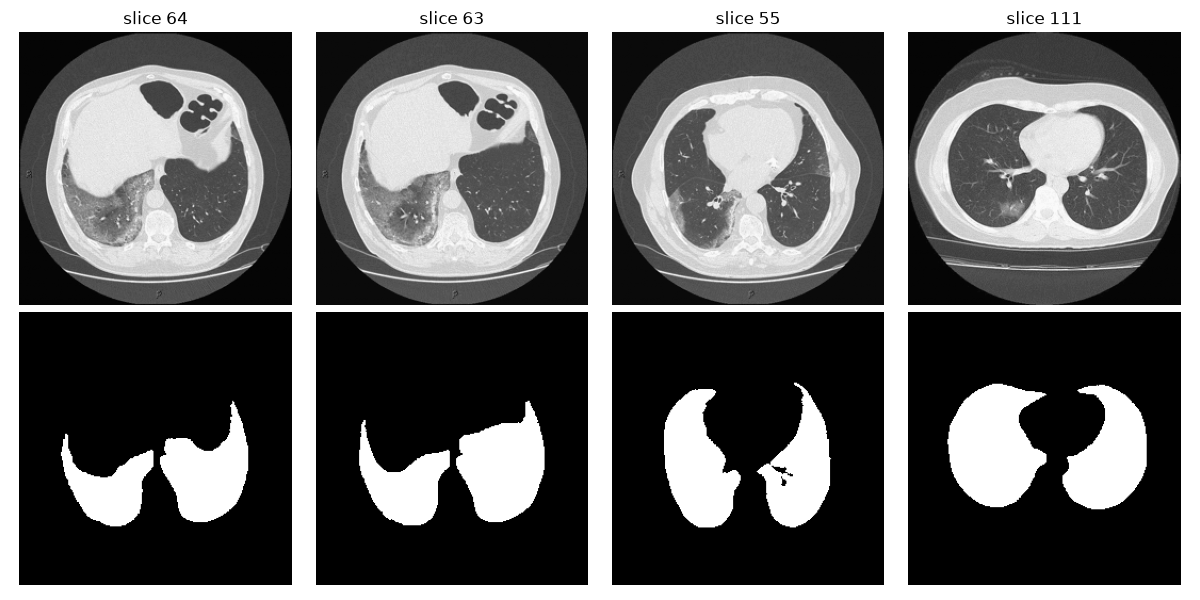

In [11]:
def show_pairs(ds, n=4):
    # Random choice of pairs
    idxs = np.random.choice(len(ds), n, replace=False)
    fig, axs = plt.subplots(2, n, figsize=(3 * n, 6))
    for i, idx in enumerate(idxs):
        img, msk = ds[idx]
        axs[0, i].imshow(img[0], cmap="gray")
        axs[0, i].set_title(f"slice {idx}")
        axs[0, i].axis("off")
        axs[1, i].imshow(msk[0], cmap="gray")
        axs[1, i].axis("off")

    plt.tight_layout()
    plt.show()


show_pairs(train_ds)

## 2. U-Net segmentation

[U-Net (Ronneberger et al., 2015)](https://arxiv.org/abs/1505.04597) is still the
reference architecture for medical image segmentation. Its core ideas are:

- a **contracting path** (encoder) that captures larger-scale image context via successive `Conv → ReLU → Pool`,
- a **symmetric expanding path** (decoder) that recovers the original image resolution,
- **skip connections** copying encoder feature maps to the decoder so that fine spatial
  details are preserved.

![U-Net](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)

### 2.1 U-Net implementation

The implementation used in this notebook follows the same overall architecture but includes several updates commonly used in modern deep-learning frameworks:
- `BatchNorm` layers are added after each convolution to make training faster and more stable,
- convolutions use `padding=1`, preserving the feature-map size and avoiding the cropping operations required in the original paper,
- the network starts with 32 channels instead of 64, reducing memory usage and training time,

These changes simplify the implementation while preserving the key ideas of U-Net: multi-scale feature extraction, skip connections and dense pixel-wise prediction.

In [12]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        # Two 3x3 conv (padding=1), each followed by BatchNorm2d and ReLU(inplace=True).
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.enc4 = DoubleConv(base * 4, base * 8)
        self.bottleneck = DoubleConv(base * 8, base * 16)

        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.head = nn.Conv2d(base, out_ch, 1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)  # logits


unet = UNet().to(device)
print(sum(p.numel() for p in unet.parameters()) / 1e6, "M parameters")

7.762465 M parameters


### 2.2 Loss, metric and training loop

A common choice for medical image segmentation is the Dice loss, which directly optimizes the overlap between the predicted and reference masks.

In this tutorial, we combine Binary Cross Entropy (BCE) and Dice losses.

BCE measures the pixel-wise classification error:

$$
L_{\mathrm{BCE}}
=
-\frac{1}{N}
\sum_i
\left[
y_i \log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

Dice measures the overlap between predicted (P) and Ground Truth (G) masks:

$$
\mathrm{Dice}
=
\frac{2|P \cap G|}
{|P| + |G|}
\qquad
L_{\mathrm{Dice}}
=
1-\mathrm{Dice}
$$

The training loss is:

$$
L
=
0.5\,L_{\mathrm{BCE}}
+
0.5\,L_{\mathrm{Dice}}
$$

BCE focuses on individual pixels, while Dice focuses on the global overlap of the segmented structure. The two losses therefore provide complementary training signals.

Feel free to experiment with different weights or even use Dice alone and observe the impact on convergence and final performance.

The Dice loss is computed over the whole mini-batch ("batch Dice"), a formulation commonly used in modern segmentation pipelines.

Although training uses a combination of losses, we report the **Dice score** on the validation set, as it is the most widely used metric in lung segmentation studies.

In [13]:
def dice_loss(logits, target, eps=1e-6):
    # Convert logits into probabilities in [0, 1]
    probs = torch.sigmoid(logits)

    intersection = (probs * target).sum()
    union = probs.sum() + target.sum()

    dice = (2 * intersection + eps) / (union + eps)

    return 1 - dice


def combo_loss(logits, target, lambda_bce=0.5, lambda_dice=0.5):
    bce = F.binary_cross_entropy_with_logits(logits, target)
    dice = dice_loss(logits, target)

    return lambda_bce * bce + lambda_dice * dice


def dice_score(logits, target, threshold=0.5, eps=1e-6):
    with torch.no_grad():

        probs = torch.sigmoid(logits)
        pred = (probs > threshold).float()

        intersection = (pred * target).sum(dim=(1, 2, 3))
        union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

        dice = (2 * intersection + eps) / (union + eps)

        return dice.mean().item()

### 2.3 Training loop

Training a neural network consists of repeatedly updating its parameters to minimize the loss function.

For each mini-batch:

1. A **forward pass** computes the segmentation prediction.
2. The **loss** measures the difference between prediction and ground truth.
3. During the **backward pass**, gradients of the loss with respect to all network parameters are computed.
4. The **optimizer** uses these gradients to update the model weights.

In this tutorial, we use **AdamW**, a widely used optimizer that adapts the learning rate of each parameter during training.

The **learning rate** (`lr`) controls the size of the weight updates:
- too large: training may become unstable,
- too small: convergence may be very slow.

We also use a **learning rate scheduler**, which gradually decreases the learning rate during training to improve convergence.

The most important parameters are:
- `epochs`: number of passes through the training dataset,
- `lr`: initial learning rate,
- `lambda_bce`: weight of the BCE loss,
- `lambda_dice`: weight of the Dice loss.

At the end of each epoch, the model is evaluated on an independent validation set and the validation Dice score is reported.

In [14]:
def train_segmenter(
    model, train_loader, val_loader, epochs=10, lr=1e-3, lambda_bce=0.5, lambda_dice=0.5
):
    # Move the model to CPU or GPU
    model.to(device)

    # AdamW optimizer updates the network weights during training
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    # Gradually decreases the learning rate over the epochs
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    history = {"train_loss": [], "val_dice": [], "val_loss": []}

    for ep in range(epochs):

        # Enable training mode (dropout, batch norm, ...)
        model.train()
        running = 0.0

        for x, y in tqdm(train_loader, desc=f"epoch {ep+1}/{epochs}", leave=False):
            x, y = x.to(device), y.to(device)

            # Reset gradients from the previous iteration
            opt.zero_grad()

            # Forward pass + loss computation
            loss = combo_loss(model(x), y, lambda_bce, lambda_dice)

            # Backward pass: compute gradients
            loss.backward()

            # Update model weights using the gradients
            opt.step()

            running += loss.item()

        # Update learning rate according to the scheduler
        sched.step()

        # Switch to evaluation mode
        model.eval()

        # Evaluation on the independent validation dataset
        val_running = 0.0
        dices = []

        # No gradient computation needed during validation
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)

                logits = model(x)

                val_running += combo_loss(logits, y, lambda_bce, lambda_dice).item()
                dices.append(dice_score(logits, y))

        history["train_loss"].append(running / len(train_loader))
        history["val_loss"].append(val_running / len(val_loader))
        history["val_dice"].append(float(np.mean(dices)))

        print(
            f"epoch {ep+1}/{epochs}: "
            f"train loss={history['train_loss'][-1]:.4f}  "
            f"val loss={history['val_loss'][-1]:.4f}  "
            f"val Dice={history['val_dice'][-1]:.4f}"
        )

    return history


# Few minutes. You can reduce to 5-6 epochs if you work on CPU.
history = train_segmenter(
    unet,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-3,
    lambda_bce=0.5,
    lambda_dice=0.5,
)

epoch 1/10: train loss=0.5443  val loss=0.7311  val Dice=0.0216


epoch 2/10: train loss=0.3933  val loss=0.4676  val Dice=0.6921


epoch 3/10: train loss=0.3097  val loss=0.2687  val Dice=0.9579


epoch 4/10: train loss=0.2407  val loss=0.2210  val Dice=0.9674


epoch 5/10: train loss=0.1944  val loss=0.1849  val Dice=0.9613


epoch 6/10: train loss=0.1606  val loss=0.1554  val Dice=0.9727


epoch 7/10: train loss=0.1400  val loss=0.1400  val Dice=0.9707


epoch 8/10: train loss=0.1283  val loss=0.1344  val Dice=0.9724


epoch 9/10: train loss=0.1220  val loss=0.1297  val Dice=0.9741


epoch 10/10: train loss=0.1204  val loss=0.1281  val Dice=0.9738


### 2.4 Training convergence analysis

A first step after training is to analyze the evolution of the loss on both the training and validation datasets.

Both curves should decrease over time and remain relatively close. A large gap between training and validation losses may indicate overfitting, meaning that the model has learned the training data too specifically and does not generalize well to unseen examples.

Conversely, if both losses remain high or decrease very slowly, the model may be underfitting, indicating that it has not learned the task sufficiently. This can result from an insufficient number of training epochs, a model that is too simple, or suboptimal training parameters.

In practice, a slight difference between the two curves is expected, but the validation loss should remain stable and not increase significantly during the final epochs.

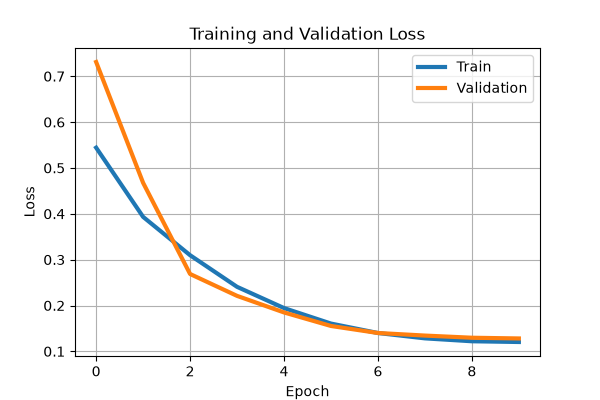

In [15]:
plt.figure(figsize=(6, 4))

plt.plot(history["train_loss"], label="Train", linewidth=3)
plt.plot(history["val_loss"], label="Validation", linewidth=3)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

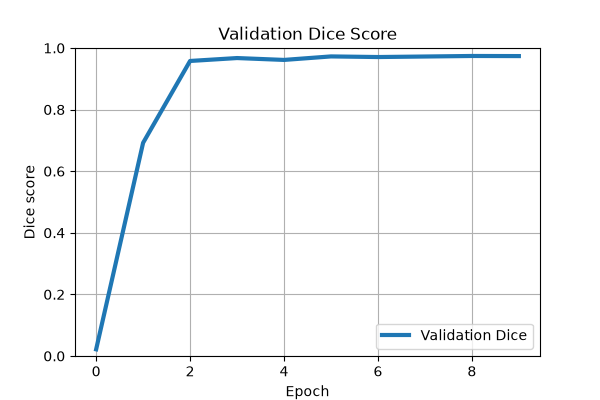

In [16]:
plt.figure(figsize=(6, 4))

plt.plot(history["val_dice"], label="Validation Dice", linewidth=3)

plt.xlabel("Epoch")
plt.ylabel("Dice score")
plt.title("Validation Dice Score")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

plt.show()

### 2.5 Evaluation on the independent test dataset

The final model is evaluated on the independent test dataset, which was not used during training, hyperparameters optimization or model selection.

While quantitative metrics provide an objective measure of performance, visual inspection remains an important part of segmentation evaluation. It helps identify potential failure modes that may not be obvious from aggregate statistics alone.

The following examples show randomly selected test slices together with their ground-truth and predicted masks.

In [17]:
test_dices = []

with torch.no_grad():
    for img, mask in test_ds:
        logits = unet(img.unsqueeze(0).to(device))

        test_dices.append(dice_score(logits, mask.unsqueeze(0).to(device)))

test_dices = np.asarray(test_dices)

print(f"N = {len(test_dices)} test slices")
print(f"Mean Dice   = {test_dices.mean():.4f}")
print(f"Median Dice = {np.median(test_dices):.4f}")
print(f"Min Dice    = {test_dices.min():.4f}")
print(f"Max Dice    = {test_dices.max():.4f}")

N = 79 test slices
Mean Dice   = 0.9650
Median Dice = 0.9819
Min Dice    = 0.7834
Max Dice    = 0.9914


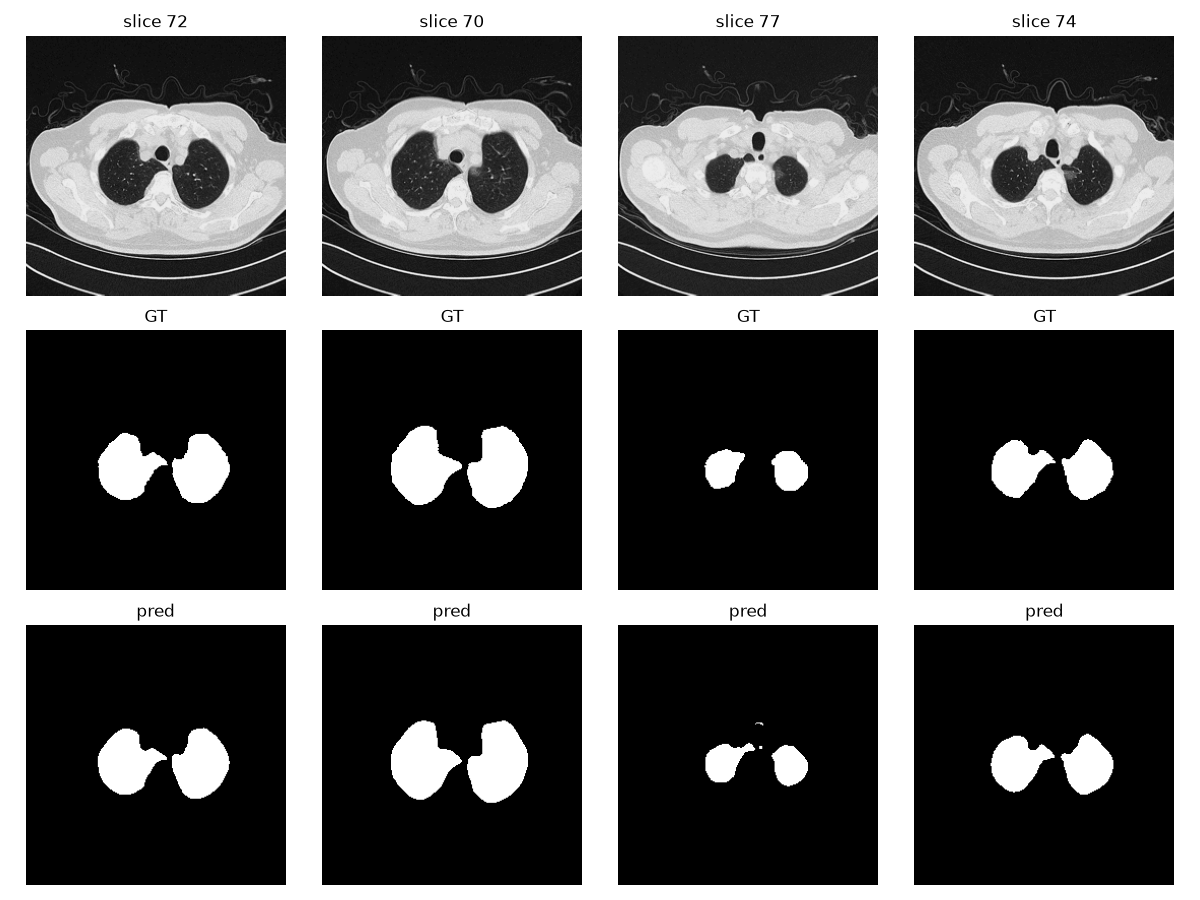

In [18]:
def show_predictions(model, ds, n=4):
    model.eval()
    idxs = np.random.choice(len(ds), n, replace=False)
    fig, axs = plt.subplots(3, n, figsize=(3 * n, 9))
    for i, idx in enumerate(idxs):
        img, msk = ds[idx]
        with torch.no_grad():
            pred = torch.sigmoid(model(img.unsqueeze(0).to(device)))[0, 0].cpu().numpy()
        axs[0, i].imshow(img[0], cmap="gray")
        axs[0, i].set_title(f"slice {idx}")
        axs[0, i].axis("off")
        axs[1, i].imshow(msk[0], cmap="gray")
        axs[1, i].set_title("GT")
        axs[1, i].axis("off")
        axs[2, i].imshow(pred > 0.5, cmap="gray")
        axs[2, i].set_title("pred")
        axs[2, i].axis("off")
    plt.tight_layout()
    plt.show()


show_predictions(unet, test_ds)

### 2.6 nnU-Net - informational only

[nnU-Net (Isensee et al., Nat. Methods 2021)](https://www.nature.com/articles/s41592-020-01008-z) is one of the most influential medical image segmentation frameworks, as it is still obtains state-of-the art performance on segmentation tasks.

A common misconception is that nnU-Net is a new neural network architecture. In reality, its main contribution is a **self-configuring pipeline** built around U-Net architecture. Given a new dataset, nnU-Net automatically determines many design choices that researchers would normally tune manually:

- **preprocessing**: image resampling and intensity normalization;
- **network configuration**: 2D or 3D model, patch size, network depth and number of channels;
- **training strategy**: data augmentation, learning rate schedule, loss function and optimization parameters;
- **inference strategy**: sliding-window prediction and test-time augmentation.

One of the key strengths of nnU-Net is that it combines **strong automatic hyperparameter selection** with **model ensembling**.

During training, nnU-Net trains several models using cross-validation folds. Rather than keeping only the best model, predictions from all trained models are combined at inference time (typically by averaging their probability maps). The intuition is simple: different models make different errors. By aggregating several models, random mistakes tend to cancel out, leading to more robust and accurate segmentations.

As a result, part of nnU-Net's performance comes not only from its automatic configuration strategy, but also from the fact that its final prediction is produced by an ensemble of multiple models rather than a single network.

## 3. SAM - promptable foundational model

The [Segment Anything Model (Kirillov et al., 2023)](https://arxiv.org/abs/2304.02643)
was trained on 1B masks from 11M natural images. Its key idea is a **promptable**
interface: given an image *and* a prompt (a point, a box, a rough mask or text), it
outputs a valid segmentation of the region the user meant. It is a Transformer-based
architecture for promptable image segmentation, with three components:

- a **ViT image encoder** (heavy, run once per image),
- a lightweight **prompt encoder** (embeds points/boxes/masks),
- a **mask decoder** (two-way transformer) predicting three candidate masks + an IoU score.

![SAM diagram](https://github.com/facebookresearch/segment-anything/raw/main/assets/model_diagram.png?raw=true)

For medical images SAM is a strong *zero-shot* baseline but was not trained on grayscale medical modalities.However, we use SAM in this lab because it introduced promptable segmentation and remains the reference model on which variants are built.

Several medical adaptations have since been proposed, you could explore by yourself:

- **[MedSAM](https://www.nature.com/articles/s41467-024-44824-z)** fine-tunes SAM on more than 1.5 million medical image-mask pairs covering multiple modalities and anatomies, improving performance on a wide range of medical segmentation tasks.

- **[MedSAM2](https://arxiv.org/abs/2504.03600)** extends the SAM2 architecture to medical imaging and supports both 3D images and medical videos.

In practice, MedSAM and MedSAM2 often outperform the original SAM on medical datasets. However, SAM remains an important reference model and provides a useful introduction to modern foundation models for image segmentation.

In [19]:
from segment_anything import build_sam_vit_b, SamPredictor

sam_model = build_sam_vit_b(ckpt).to(device).eval()
print(f"Total params: {sum(p.numel() for p in sam_model.parameters()):,}")
print(
    f"Image encoder: {sum(p.numel() for p in sam_model.image_encoder.parameters()):,}"
)
print(
    f"Prompt encoder: {sum(p.numel() for p in sam_model.prompt_encoder.parameters()):,}"
)
print(f"Mask decoder: {sum(p.numel() for p in sam_model.mask_decoder.parameters()):,}")

Total params: 93,735,472
Image encoder: 89,670,912
Prompt encoder: 6,220
Mask decoder: 4,058,340


SAM follows an asymmetric design. Most of the model capacity is allocated to the ViT image encoder, which learns general-purpose visual representations. The prompt encoder and mask decoder contain far fewer parameters, enabling efficient interactive segmentation once image features have been computed.

In practice, these components can be fine-tuned to a specific application. Many SAM adaptations, including MedSAM, are obtained by fine-tuning part or all of the original architecture on medical datasets. In this lab, however, we use a frozen pre-trained model and perform inference only.

### 3.1 Box prompt segmentation

In SAM, the segmentation result is conditioned by the prompt provided to the model. A bounding box gives strong spatial information about the target object and generally leads to more accurate segmentations than sparse point prompts.

In this exercise, the bounding box is automatically derived from the reference mask. This allows us to evaluate the segmentation capabilities of SAM under ideal prompting conditions, independently of any variability introduced by the user.

The workflow consists of encoding the image once, providing the bounding box prompt, and predicting the corresponding segmentation mask. The resulting mask can then be compared with the reference annotation using the Dice score.

In [20]:
def to_rgb_uint8(slice_2d):
    """(H, W) float in [0,1] -> (H, W, 3) uint8 (SAM expects an 8-bit RGB image)."""
    arr = (np.clip(slice_2d, 0, 1) * 255).astype(np.uint8)
    return np.stack([arr] * 3, axis=-1)


def mask_to_box(mask, pad=0):
    """Tight XYXY box around the positive pixels of a binary mask (optional padding)."""
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    H, W = mask.shape
    return np.array(
        [
            max(0, int(xs.min()) - pad),
            max(0, int(ys.min()) - pad),
            min(W - 1, int(xs.max()) + pad),
            min(H - 1, int(ys.max()) + pad),
        ],
        dtype=np.float32,
    )


def dice_np(a, b, eps=1e-6):
    a, b = a.astype(bool), b.astype(bool)
    return (2 * (a & b).sum() + eps) / (a.sum() + b.sum() + eps)

In [21]:
def sam_box_inference(sam_model, slice_2d, box_xyxy, device):
    """Run SAM on a 2D image with a bounding box prompt."""

    predictor = SamPredictor(sam_model)

    # Encode image
    predictor.set_image(to_rgb_uint8(slice_2d))

    # Decode mask from prompt
    with torch.no_grad():
        masks, _, _ = predictor.predict(
            box=np.asarray(box_xyxy, dtype=np.float32)[None, :],
            multimask_output=False,
        )

    return masks[0].astype(np.uint8)

Dice SAM (box): 0.968


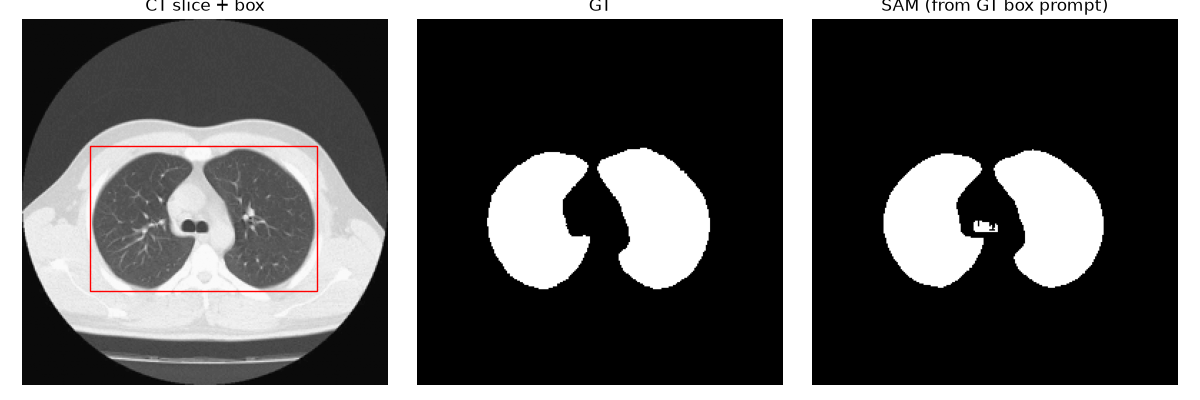

In [22]:
img_t, msk_t = test_ds[20]
slice_ct = img_t[0].numpy()  # (H, W) in [0, 1]
gt = msk_t[0].numpy().astype(np.uint8)
box = mask_to_box(gt, pad=2)

pred_box = sam_box_inference(sam_model, slice_ct, box, device)
print("Dice SAM (box):", round(dice_np(pred_box, gt), 3))

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(slice_ct, cmap="gray")
axs[0].add_patch(
    plt.Rectangle(
        (box[0], box[1]),
        box[2] - box[0],
        box[3] - box[1],
        fill=False,
        edgecolor="red",
    )
)
axs[0].set_title("CT slice + box")
axs[0].axis("off")
axs[1].imshow(gt, cmap="gray")
axs[1].set_title("GT")
axs[1].axis("off")
axs[2].imshow(pred_box, cmap="gray")
axs[2].set_title("SAM (from GT box prompt)")
axs[2].axis("off")
plt.tight_layout()
plt.show()

### 3.2 Click-based point prompts (interactive)

Same idea as the LAB SAM notebook: click positive points (**left click**, green) on the
lungs and optionally some negative points (**right click**, red) outside the lungs.
Then run the next cell to feed those points to SAM.

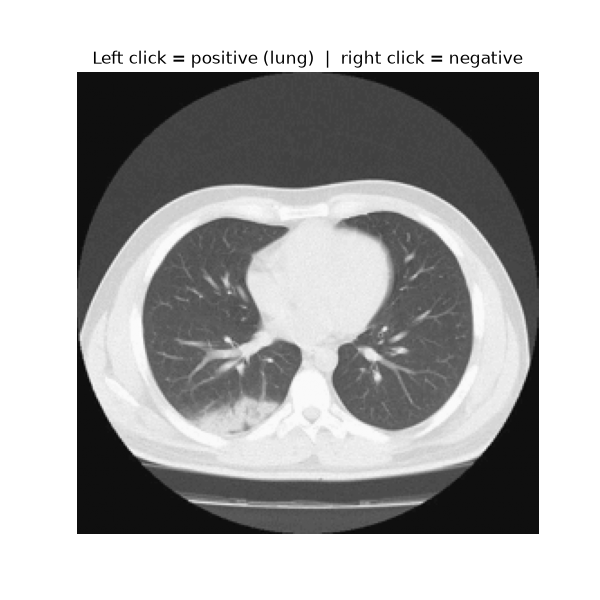

In [24]:
%matplotlib widget

# Pick one test slice, prepare the click canvas.
idx = 10
img_t, msk_t = test_ds[idx]
slice_ct = img_t[0].numpy()
gt = msk_t[0].numpy().astype(np.uint8)

click_points, click_labels = [], []


def _on_click(event, ax):
    if event.inaxes is not ax or event.xdata is None:
        return
    label = 1 if event.button == 1 else 0  # left=positive, right=negative
    click_points.append([float(event.xdata), float(event.ydata)])
    click_labels.append(label)
    ax.scatter(
        event.xdata,
        event.ydata,
        c="lime" if label == 1 else "red",
        s=80,
        edgecolor="white",
        zorder=5,
    )
    event.canvas.draw_idle()


fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(slice_ct, cmap="gray")
ax.set_title("Left click = positive (lung)  |  right click = negative")
ax.axis("off")
fig.canvas.mpl_connect("button_press_event", lambda e: _on_click(e, ax))
plt.show()


prompts: 3 points  |  Dice = 0.961


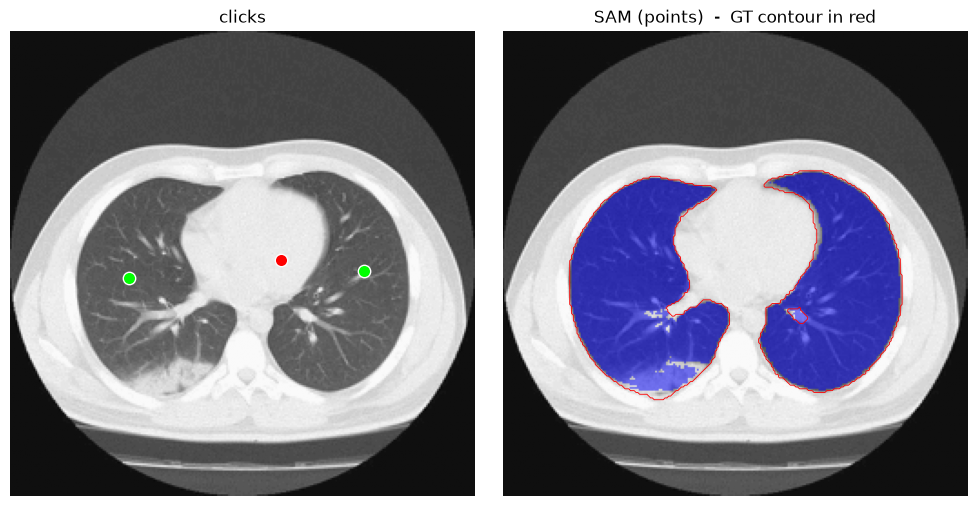

In [27]:
%matplotlib inline

# Fallback if you haven't clicked anything: two positive points on lung centroids.
if len(click_points) == 0:
    from scipy import ndimage as _nd

    lab, n = _nd.label(gt)
    if n >= 1:
        for cy, cx in _nd.center_of_mass(gt, lab, range(1, n + 1)):
            click_points.append([float(cx), float(cy)])
            click_labels.append(1)
    print("No clicks captured -> using GT lung centroids as fallback prompts.")

pts = np.array(click_points, dtype=np.float32)
lbls = np.array(click_labels, dtype=np.int32)

rgb = to_rgb_uint8(slice_ct)
predictor = SamPredictor(sam_model)
predictor.set_image(rgb)
masks, ious, _ = predictor.predict(
    point_coords=pts,
    point_labels=lbls,
    multimask_output=False,
)
pred_pt = masks[0].astype(np.uint8)

print(f"prompts: {len(pts)} points  |  Dice = {dice_np(pred_pt, gt):.3f}")

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(slice_ct, cmap="gray")
for (x, y), lb in zip(pts, lbls):
    axs[0].scatter(x, y, c="lime" if lb == 1 else "red", s=80, edgecolor="white")
axs[0].set_title("clicks")
axs[0].axis("off")
axs[1].imshow(slice_ct, cmap="gray")
axs[1].imshow(
    np.ma.masked_where(pred_pt == 0, pred_pt), alpha=0.5, cmap="winter"
)
axs[1].contour(gt, levels=[0.5], colors="red", linewidths=0.6)
axs[1].set_title("SAM (points)  -  GT contour in red")
axs[1].axis("off")
plt.tight_layout()
plt.show()


### 3.3 Automatic mask generation

So far, SAM has been guided using explicit prompts (bounding boxes or points). However, SAM can also generate masks without user interaction.

In this mode, a dense grid of points is automatically sampled across the image. Each point is used as a prompt, producing multiple candidate masks that are subsequently filtered and merged.

Unlike a semantic segmentation model such as U-Net, SAM does not assign anatomical labels. Instead, it decomposes the image into a collection of coherent regions or objects.

The resulting masks can be visualized independently or combined into a label map, where each detected region receives a unique identifier.

In [28]:
from segment_anything import SamAutomaticMaskGenerator

# Select a test image
idx = 10
img, gt = test_ds[idx]

# Reduce the influence of very low-intensity regions
image = img[0].numpy()
image = (image - image.min()) / (image.max() - image.min())
print(image.min(), image.max())

# Clamp very low intensities to reduce the dominance of the background
image[image < 0.3] = 0.3

# SAM expects an RGB uint8 image
image = to_rgb_uint8(image)

mask_generator = SamAutomaticMaskGenerator(sam_model)

# Automatic mask generation without prompts
masks = mask_generator.generate(image)

print(f"{len(masks)} masks detected")

# Combine all masks into a label map
label_map = np.zeros(img[0].shape, dtype=np.int32)

for label, ann in enumerate(masks, start=1):
    label_map[ann["segmentation"]] = label

0.0 1.0
8 masks detected


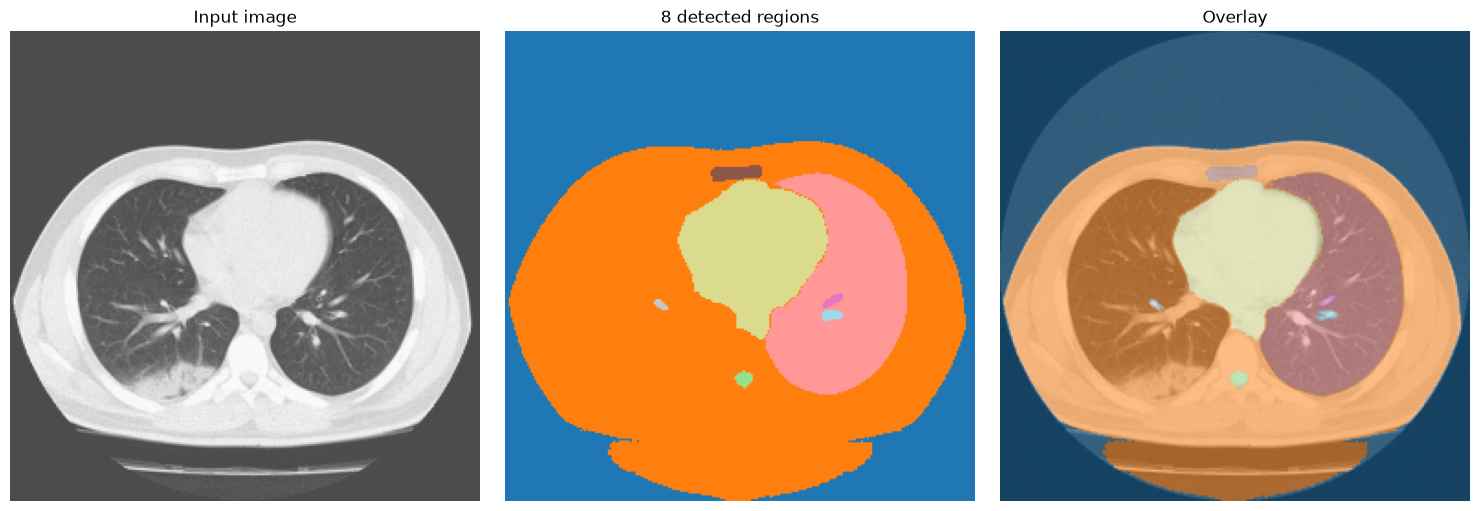

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image, cmap="gray")
ax[0].set_title("Input image")
ax[0].axis("off")

ax[1].imshow(label_map, cmap="tab20")
ax[1].set_title(f"{len(masks)} detected regions")
ax[1].axis("off")

ax[2].imshow(img[0], cmap="gray")
ax[2].imshow(label_map, cmap="tab20", alpha=0.5)
ax[2].set_title("Overlay")
ax[2].axis("off")

plt.tight_layout()
plt.show()

### 3.4 SAM on a 3D chest CT volume

CT and MRI data are inherently 3D, whereas SAM was originally designed for 2D images. Applying SAM to a volume therefore requires a strategy to transfer information between neighboring slices.

Here, we start from a single manually initialized slice. SAM predicts a segmentation mask on this slice, and the bounding box of the predicted mask is then used as the prompt for the next slice. This process is repeated throughout the volume, allowing the segmentation to propagate automatically from slice to slice.

This simple approach exploits an important property of medical volumes: anatomical structures usually evolve smoothly between adjacent slices, making the segmentation of one slice a useful prior for the next.

Case: radiopaedia_4_85506_1.nii.gz
CT shape    : (39, 630, 630)
Mask shape  : (39, 630, 630)
Spacing (mm): (0.68, 0.68, 6.00)


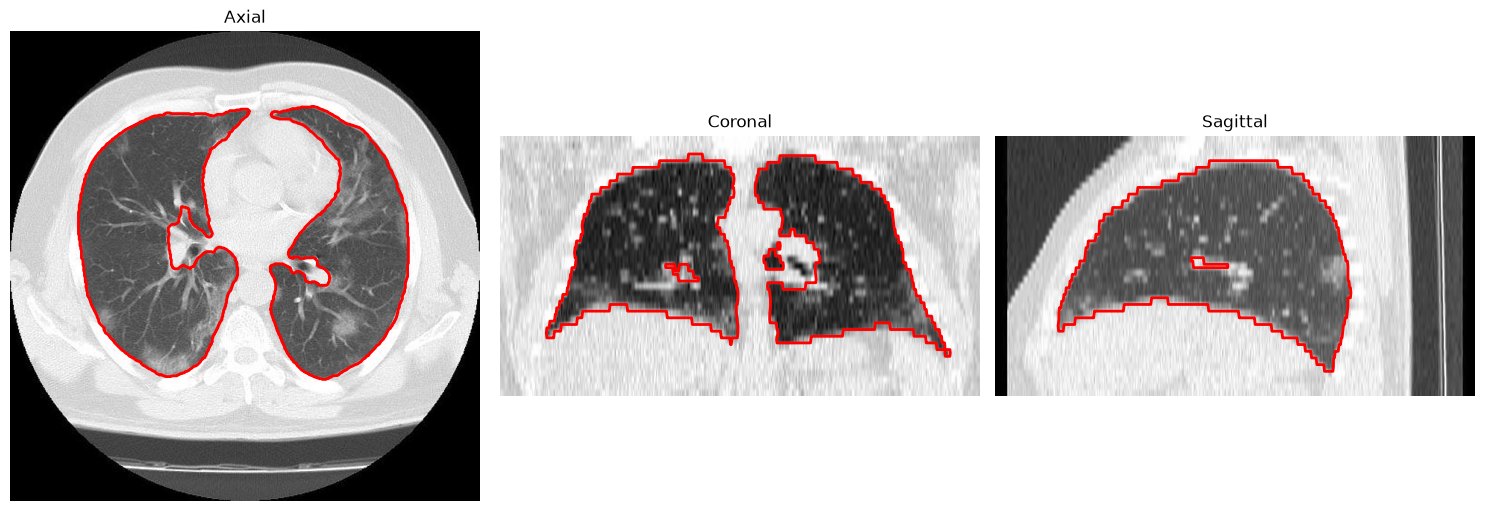

In [46]:
CT_NAME = CT_CASES[0]

img_sitk = sitk.ReadImage(str(CT_IMG_DIR / CT_NAME))
mask_sitk = sitk.ReadImage(str(CT_MASK_DIR / CT_NAME))

# SimpleITK: (x,y,z) -> NumPy: (z,y,x)
VOLUME_RAW = sitk.GetArrayFromImage(img_sitk).astype(np.float32)
MASK3D = sitk.GetArrayFromImage(mask_sitk).astype(np.uint8)

VOLUME = ct_window(VOLUME_RAW)

# Physical voxel spacing (mm)
sx, sy, sz = img_sitk.GetSpacing()

print(f"Case: {CT_NAME}")
print(f"CT shape    : {VOLUME.shape}")
print(f"Mask shape  : {MASK3D.shape}")
print(f"Spacing (mm): ({sx:.2f}, {sy:.2f}, {sz:.2f})")

z, y, x = [s // 2 for s in VOLUME.shape]

# Flip superior/inferior direction for a more intuitive orientation
coronal = np.flipud(VOLUME[:, y, :])
coronal_mask = np.flipud(MASK3D[:, y, :])

sagittal = np.flipud(VOLUME[:, :, x - 100])
sagittal_mask = np.flipud(MASK3D[:, :, x - 100])

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Axial
axs[0].imshow(VOLUME[z], cmap="gray")
axs[0].contour(MASK3D[z], levels=[0.5], colors="red", linewidths=2)
axs[0].set_title("Axial")

# Coronal
axs[1].imshow(coronal, cmap="gray", aspect=sz / sx)
axs[1].contour(coronal_mask, levels=[0.5], colors="red", linewidths=2)
axs[1].set_title("Coronal")

# Sagittal
axs[2].imshow(sagittal, cmap="gray", aspect=sz / sy)
axs[2].contour(sagittal_mask, levels=[0.5], colors="red", linewidths=2)
axs[2].set_title("Sagittal")

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()

Seed slice: 16
Seed box: [ 76  87 552 475]
3D Dice (box propagation): 0.638


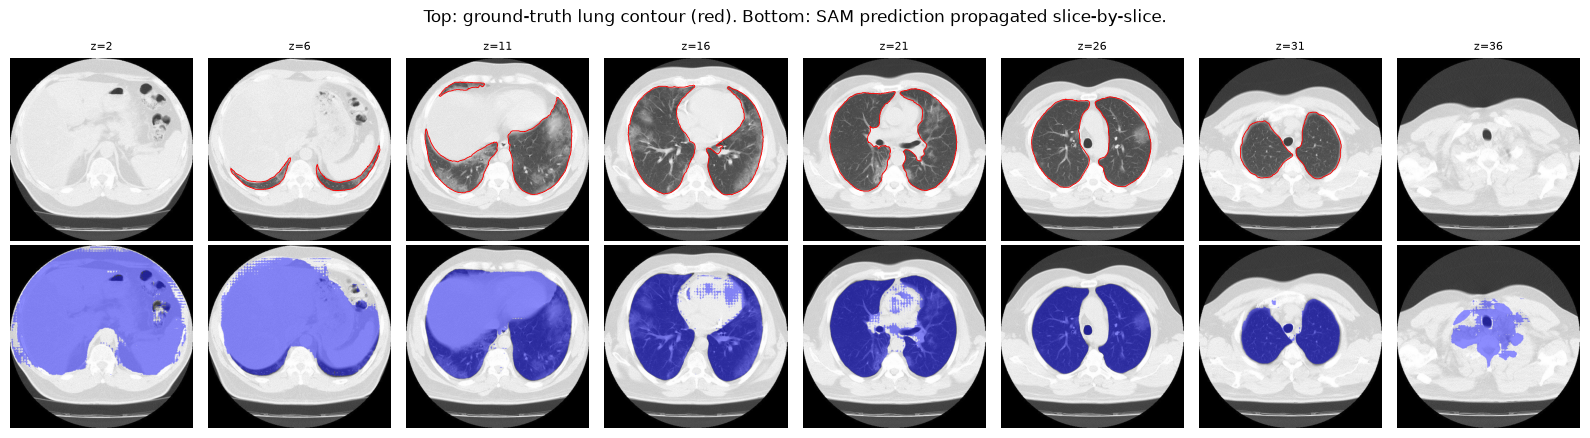

In [47]:
# Start from one slice where the lungs are large and easy to localize.
# SAM segments this slice from a bounding box prompt.
# The predicted mask is then converted into a new box, which is reused
# on the neighboring slice. Repeating this process propagates the
# segmentation through the whole volume.


def propagate_sam(volume, seed_box, seed_z, sam_model, device, pad=6):
    D = volume.shape[0]
    pred = np.zeros_like(volume, dtype=np.uint8)

    # Forward propagation (toward larger z)
    box = seed_box
    for z in range(seed_z, D):
        if box is None:
            break

        pred[z] = sam_box_inference(
            sam_model,
            volume[z],
            box,
            device,
        )

        # Use the current prediction to define the next prompt box
        box = mask_to_box(pred[z], pad=pad)

    # Backward propagation (toward smaller z)
    box = mask_to_box(pred[seed_z], pad=pad) if pred[seed_z].sum() else seed_box

    for z in range(seed_z - 1, -1, -1):
        if box is None:
            break

        pred[z] = sam_box_inference(
            sam_model,
            volume[z],
            box,
            device,
        )

        box = mask_to_box(pred[z], pad=pad)

    return pred


# Use the slice with the largest lung area as the initialization slice
seed_z = int(np.argmax(MASK3D.sum(axis=(1, 2))))
seed_box = mask_to_box(MASK3D[seed_z], pad=6)

print("Seed slice:", seed_z)
print("Seed box:", seed_box.astype(int))

# Propagate the segmentation through the volume
pred_vol = propagate_sam(
    VOLUME,
    seed_box,
    seed_z,
    sam_model,
    device,
    pad=6,
)

d3 = dice_np(pred_vol, MASK3D)
print(f"3D Dice (box propagation): {d3:.3f}")


# Visualize a few slices across the volume
show_z = np.linspace(2, VOLUME.shape[0] - 3, 8).astype(int)

fig, axs = plt.subplots(
    2,
    len(show_z),
    figsize=(2.0 * len(show_z), 4.5),
)

for i, z in enumerate(show_z):

    # Ground truth
    axs[0, i].imshow(VOLUME[z], cmap="gray")
    axs[0, i].contour(
        MASK3D[z],
        levels=[0.5],
        colors="red",
        linewidths=0.6,
    )
    axs[0, i].set_title(f"z={z}", fontsize=8)
    axs[0, i].axis("off")

    # Propagated SAM prediction
    axs[1, i].imshow(VOLUME[z], cmap="gray")
    axs[1, i].imshow(
        np.ma.masked_where(pred_vol[z] == 0, pred_vol[z]),
        cmap="winter",
        alpha=0.45,
    )
    axs[1, i].axis("off")

plt.suptitle(
    "Top: ground-truth lung contour (red). "
    "Bottom: SAM prediction propagated slice-by-slice."
)
plt.tight_layout()
plt.show()

The slice-by-slice propagation strategy implemented above provides a simple way to extend a 2D model to a 3D volume. However, more advanced foundation models have recently been developed to better handle temporal and volumetric data.

- [SAM 2](https://ai.meta.com/research/publications/sam-2-segment-anything-in-images-and-videos/) introduces a memory mechanism that s information across a sequence of images. A 3D volume can be interpreted as a sequence of slices, enabling more consistent segmentation across the volume.

- [MedSAM2](https://arxiv.org/abs/2504.03600) adapts this paradigm to medical imaging and extends it to 3D medical volumes and videos. Trained on large-scale medical datasets, it generally provides stronger performance and requires less manual interaction than the simple propagation strategy explored in this lab.

## 4. ViT foundational backbone with DINOv2

The https://arxiv.org/abs/2304.07193
model is a large **self-supervised Vision Transformer (ViT)** trained on 142M natural images. Unlike U-Net or SAM, it is not a segmentation model. Instead, it learns generic visual representations from unlabeled data that transfer well across a wide range of downstream tasks.

Its key idea is to map image patches into a rich **embedding space**, where semantically similar structures have similar representations. The architecture consists of:

- a **ViT backbone** that converts the image into patch tokens,
- a self-supervised **DINO learning objective** that requires no manual annotations,
- a set of **patch embeddings** that can be reused for downstream tasks.

Vision transformer architecture:
![ViT](https://viso.ai/wp-content/uploads/2021/09/vision-transformer-vit.png)

Although DINOv2 is not a segmentation model, its patch embeddings provide a powerful feature space for dense prediction tasks such as segmentation.

In [ ]:
def build_dino(model_type="vits"):
    return torch.hub.load("facebookresearch/dinov2", f"dinov2_{model_type}14")


DINO_MODEL = "vits"
DINO_FEATURE_DIM = {"vits": 384, "vitb": 768, "vitl": 1024, "vitg": 1536}

dino = build_dino(DINO_MODEL).to(device).eval()
for p in dino.parameters():
    p.requires_grad = False

Using cache found in C:\Users\250007508/.cache\torch\hub\facebookresearch_dinov2_main


### 4.1 A DINOv2-backed segmenter

DINOv2 uses a patch size of 14, so we resize inputs to a multiple of 14 and
reshape the sequence of patch tokens back into a 2D grid before the decoder.

The decoder here is intentionally tiny: two `Conv+ReLU` blocks and bilinear
upsampling. If it already reaches a decent Dice, it means the frozen features carry
most of the semantic information, demonstrating the strength of foundation models.

In [59]:
DINO_SIZE = 224


class DinoSegmenter(nn.Module):
    def __init__(self, dino, feat_dim=384):
        super().__init__()
        self.dino = dino

        # Small segmentation head operating on DINO patch features
        self.decoder = nn.Sequential(
            nn.Conv2d(feat_dim, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, 1),
        )

    def forward(self, x):
        x = x.repeat(1, 3, 1, 1)  # grayscale -> RGB

        with torch.no_grad():
            tokens = self.dino.forward_features(x)["x_norm_patchtokens"]

        B, N, C = tokens.shape
        grid = int(N**0.5)  # 256 tokens -> 16 x 16 grid

        feat = tokens.transpose(1, 2).reshape(B, C, grid, grid)
        mask = self.decoder(feat)

        return F.interpolate(
            mask,
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

### 4.2 Train the DINOv2-backed segmenter

DINOv2 uses a **patch size of 14**, so we rebuild loaders at `224 x 224` (multiple of
14). Only the tiny decoder trains — the ViT is frozen. Same training loop as the U-Net.


epoch 1/5: train loss=0.2208  val loss=0.2706  val Dice=0.7316


epoch 2/5: train loss=0.0971  val loss=0.1292  val Dice=0.8568


epoch 3/5: train loss=0.0748  val loss=0.1259  val Dice=0.8628


epoch 4/5: train loss=0.0691  val loss=0.1122  val Dice=0.8758


epoch 5/5: train loss=0.0656  val loss=0.1170  val Dice=0.8711


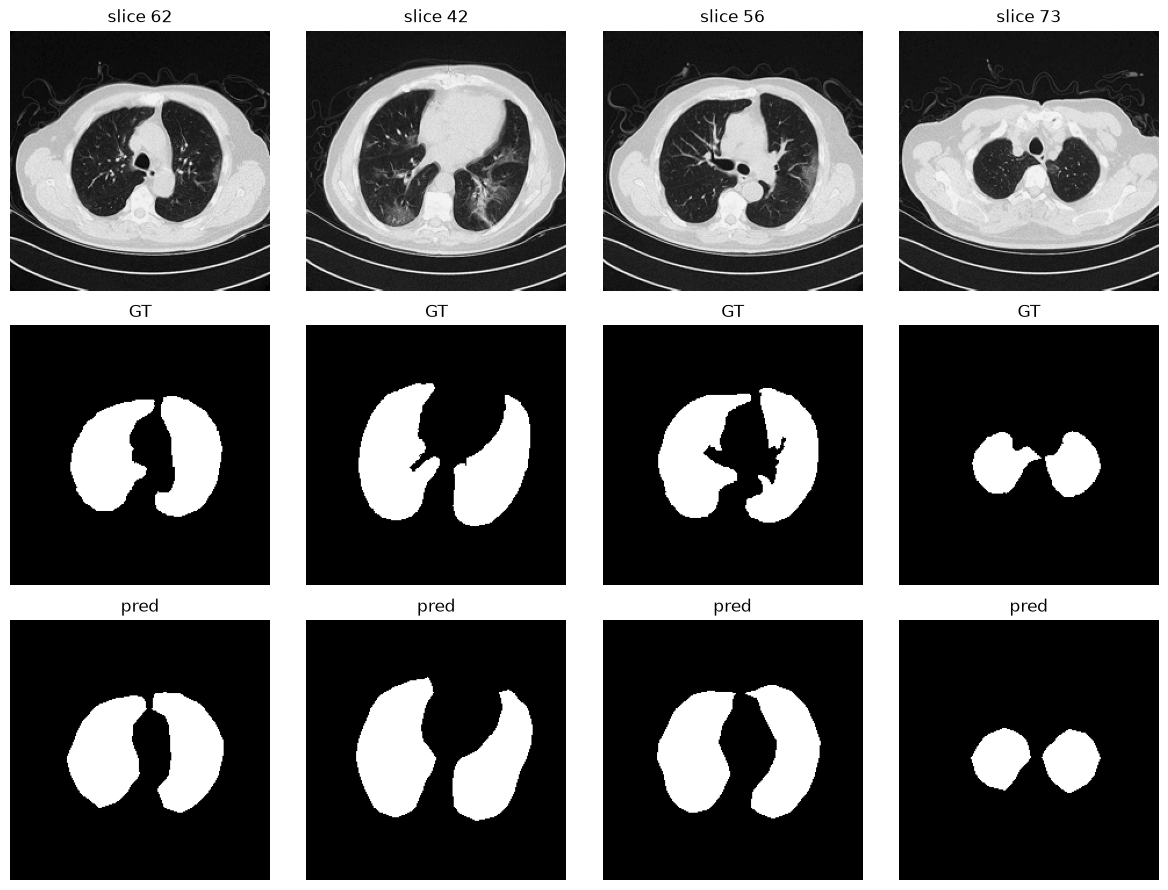

In [61]:
train_loader = DataLoader(
    LungCTDataset(CT_IMG_DIR, CT_MASK_DIR, train_cases, size=DINO_SIZE),
    batch_size=8,
    shuffle=True,
)
val_loader = DataLoader(
    LungCTDataset(CT_IMG_DIR, CT_MASK_DIR, val_cases, size=DINO_SIZE),
    batch_size=8,
)
test_ds = LungCTDataset(CT_IMG_DIR, CT_MASK_DIR, test_cases, size=DINO_SIZE)


seg = DinoSegmenter(
    dino,
    feat_dim=DINO_FEATURE_DIM[DINO_MODEL],
).to(device)

history_dino = train_segmenter(seg, train_loader, val_loader, epochs=5, lr=1e-3)
show_predictions(seg, test_ds)